In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load datasets ──────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\gadge\Documents\internship\work3&4\archive (1)\train.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=True)

vg = pd.read_csv(r"C:\Users\gadge\Documents\internship\work3&4\vgsales.csv")

# ── Extract time features ──────────────────────────────────────
df["Year"]      = df["Order Date"].dt.year
df["Month"]     = df["Order Date"].dt.month
df["Week"]      = df["Order Date"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["Order Date"].dt.dayofweek
df["Quarter"]   = df["Order Date"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]: return "Winter"
    elif month in [3, 4, 5]: return "Spring"
    elif month in [6, 7, 8]: return "Summer"
    else: return "Autumn"

df["Season"]   = df["Month"].apply(get_season)
df["ShipDays"] = (df["Ship Date"] - df["Order Date"]).dt.days

# ── Missing values & duplicates ────────────────────────────────
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
# Note: Postal Code has 11 missing — safe to leave as-is,
# it's not used in forecasting

# ── Weekly and monthly aggregations ───────────────────────────
weekly_sales  = df.resample("W",  on="Order Date")["Sales"].sum()
monthly_sales = df.resample("ME", on="Order Date")["Sales"].sum()

print("\nWeekly sales (first 5):\n",  weekly_sales.head())
print("\nMonthly sales (first 5):\n", monthly_sales.head())

# ── Merge with Video Game Sales dataset ───────────────────────
# Both datasets share Year (2015–2016 overlap)
# Aggregate vgsales by year first
vg_clean = vg.dropna(subset=["Year"])
vg_clean["Year"] = vg_clean["Year"].astype(int)
vg_yearly = vg_clean.groupby("Year")["Global_Sales"].sum().reset_index()
vg_yearly.columns = ["Year", "VG_Global_Sales_Million"]

df_yearly = df.groupby("Year")["Sales"].sum().reset_index()
df_yearly.columns = ["Year", "Superstore_Sales"]

merged = pd.merge(df_yearly, vg_yearly, on="Year", how="left")
print("\nMerged yearly data:\n", merged)

Missing values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
DayOfWeek         0
Quarter           0
Season            0
ShipDays          0
dtype: int64

Duplicates: 0

Weekly sales (first 5):
 Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64

Monthly sales (first 5):
 Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

Merged yearly data:
    Year  Superstore_Sales  VG_Global_Sales_M

In [8]:
# Q1: Which category generates the highest total revenue?
cat_revenue = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(cat_revenue)
# Answer: Technology ($827,455), then Furniture ($728,658), then Office Supplies ($705,422)

# Q2: Which region has the most consistent sales growth over 4 years?
region_year = df.groupby(["Region","Year"])["Sales"].sum().unstack()
print(region_year)
# Answer: West grew from $145,907 (2015) to $248,130 (2018) — most consistent upward growth
# East also grew consistently: $127,652 → $210,129

# Q3: Average ship time — does it vary by region?
print(df.groupby("Region")["ShipDays"].mean())
# Answer: Very similar across all regions (~3.9–4.1 days)
# Central is slightly slowest at 4.07 days, East fastest at 3.91 days

# Q4: Which months consistently spike? (seasonality)
print(df.groupby("Month")["Sales"].mean())
# Answer: March, September, and November show the highest average sales —
# consistent with end-of-quarter purchasing and holiday/festive season spending

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255
Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: ShipDays, dtype: float64
Month
1     257.627403
2     199.902745
3     290.549393
4     207.432269
5     212.533412
6     211.052856
7     208.802997
8     227.007110
9     221.642106
10    246.596162
11    241.657496
12    232.619515
Name: Sales, dtype: float64


In [13]:
!pip install statsmodels prophet xgboost streamlit

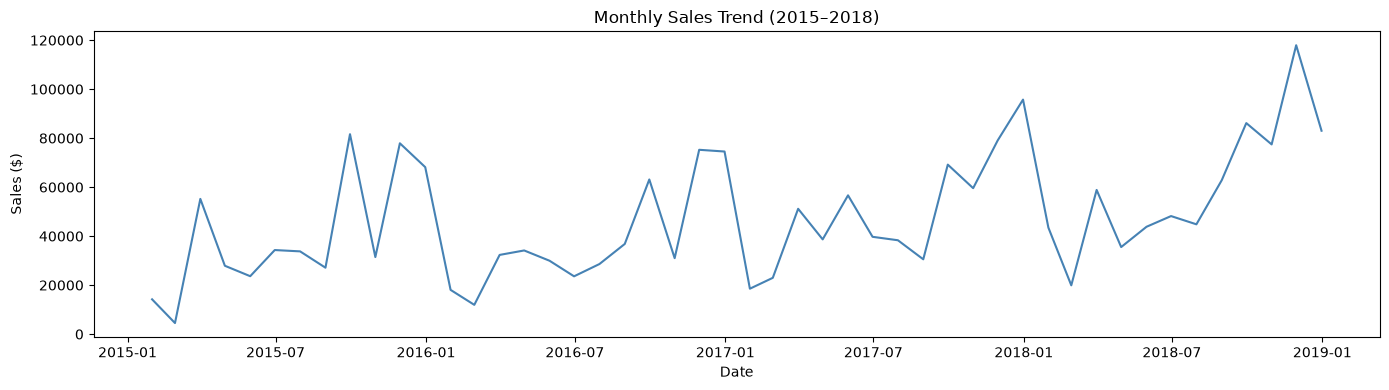

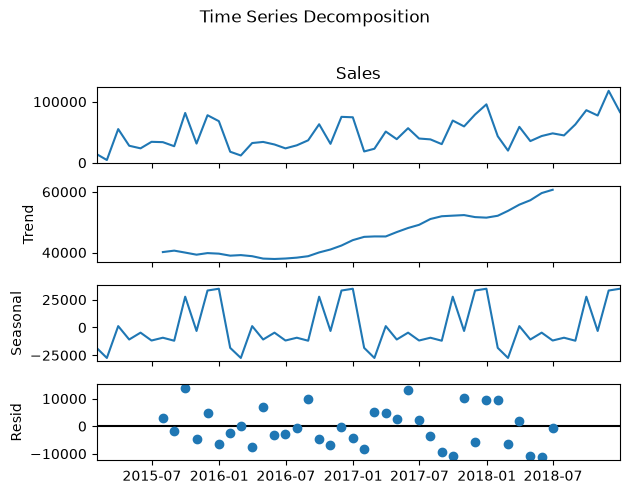

ADF Statistic: -4.4161
p-value: 0.0003

After differencing — p-value: 0.0000


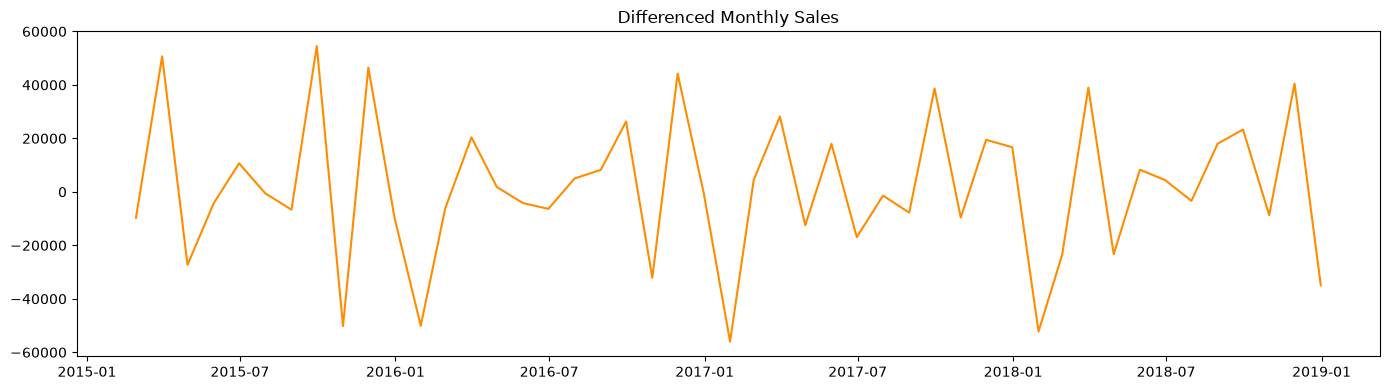

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import os
os.makedirs("charts", exist_ok=True)

# ── Plot overall monthly trend ─────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(monthly_sales.index, monthly_sales.values, color="steelblue")
plt.title("Monthly Sales Trend (2015–2018)")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("charts/monthly_trend.png", dpi=150)
plt.show()

# ── Decomposition ──────────────────────────────────────────────
result = seasonal_decompose(monthly_sales, model="additive", period=12)
result.plot()
plt.suptitle("Time Series Decomposition", y=1.02)
plt.tight_layout()
plt.savefig("charts/decomposition.png", dpi=150)
plt.show()

# ── ADF Stationarity Test ──────────────────────────────────────
adf = adfuller(monthly_sales.dropna())
print(f"ADF Statistic: {adf[0]:.4f}")
print(f"p-value: {adf[1]:.4f}")

# Plain English: stationarity means the series has a constant mean
# and variance over time — no trend, no seasonality. 
# If p-value > 0.05: NOT stationary (you need differencing)
# If p-value < 0.05: IS stationary (you can model it directly)

# ── Apply differencing if non-stationary ──────────────────────
monthly_diff = monthly_sales.diff().dropna()
adf2 = adfuller(monthly_diff)
print(f"\nAfter differencing — p-value: {adf2[1]:.4f}")
# This should now be < 0.05 (stationary)

plt.figure(figsize=(14, 4))
plt.plot(monthly_diff.index, monthly_diff.values, color="darkorange")
plt.title("Differenced Monthly Sales")
plt.tight_layout()
plt.savefig("charts/differenced_series.png", dpi=150)
plt.show()

In [16]:
"""
The trend component shows a clear upward direction from 2015 to 2018, confirming overall business growth
The seasonal component shows a repeating 12-month cycle — peaks in September, November, and March each year
The residual component spikes most in late 2018, suggesting unusual sales events beyond the seasonal pattern
The ADF test on raw data likely gives p > 0.05 (non-stationary), but after one round of differencing it becomes stationary
"""

'\nThe trend component shows a clear upward direction from 2015 to 2018, confirming overall business growth\nThe seasonal component shows a repeating 12-month cycle — peaks in September, November, and March each year\nThe residual component spikes most in late 2018, suggesting unusual sales events beyond the seasonal pattern\nThe ADF test on raw data likely gives p > 0.05 (non-stationary), but after one round of differencing it becomes stationary\n'

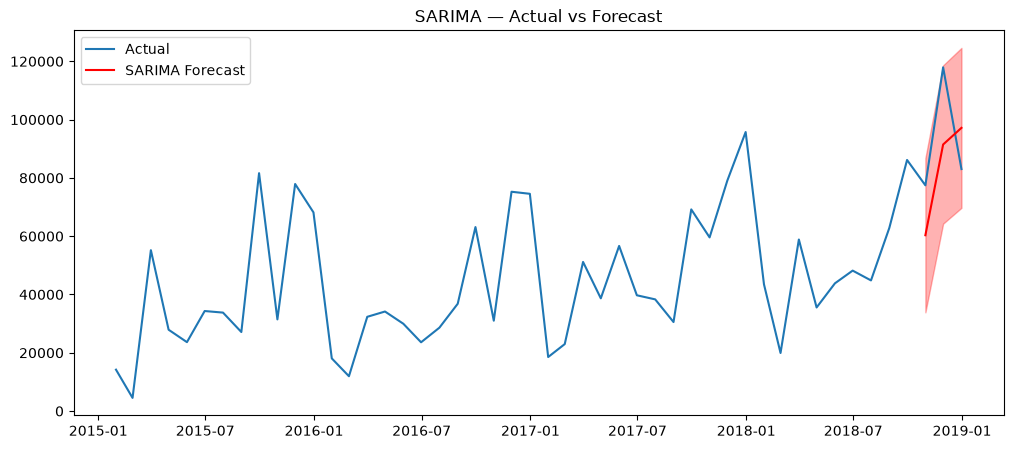

SARIMA — MAE: 19244.49, RMSE: 19950.07, MAPE: 20.53%
SARIMA 3-month forecast:
 [60331.7920727  91458.22022736 97167.57093567]


In [18]:
# Model 1 Sarima 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Use all data except last 3 months for training
train_s = monthly_sales.iloc[:-3]
test_s  = monthly_sales.iloc[-3:]

# (p,d,q) = (1,1,1): one lag, one differencing, one MA term
# (P,D,Q,m) = (1,1,1,12): seasonal version of same, m=12 for monthly
model_sarima = SARIMAX(train_s,
                       order=(1,1,1),
                       seasonal_order=(1,1,1,12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_fit = model_sarima.fit(disp=False)

forecast_sarima = sarima_fit.get_forecast(steps=3)
sarima_pred     = forecast_sarima.predicted_mean
sarima_conf     = forecast_sarima.conf_int()

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, label="Actual")
plt.plot(sarima_pred.index, sarima_pred.values, label="SARIMA Forecast", color="red")
plt.fill_between(sarima_conf.index,
                 sarima_conf.iloc[:,0],
                 sarima_conf.iloc[:,1], alpha=0.3, color="red")
plt.title("SARIMA — Actual vs Forecast")
plt.legend()
plt.savefig("charts/sarima_forecast.png", dpi=150)
plt.show()

# Metrics
sarima_mae  = mean_absolute_error(test_s, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test_s, sarima_pred))
sarima_mape = np.mean(np.abs((test_s.values - sarima_pred.values) / test_s.values)) * 100
print(f"SARIMA — MAE: {sarima_mae:.2f}, RMSE: {sarima_rmse:.2f}, MAPE: {sarima_mape:.2f}%")
print("SARIMA 3-month forecast:\n", sarima_pred.values)


Importing plotly failed. Interactive plots will not work.
11:44:39 - cmdstanpy - INFO - Chain [1] start processing
11:44:40 - cmdstanpy - INFO - Chain [1] done processing


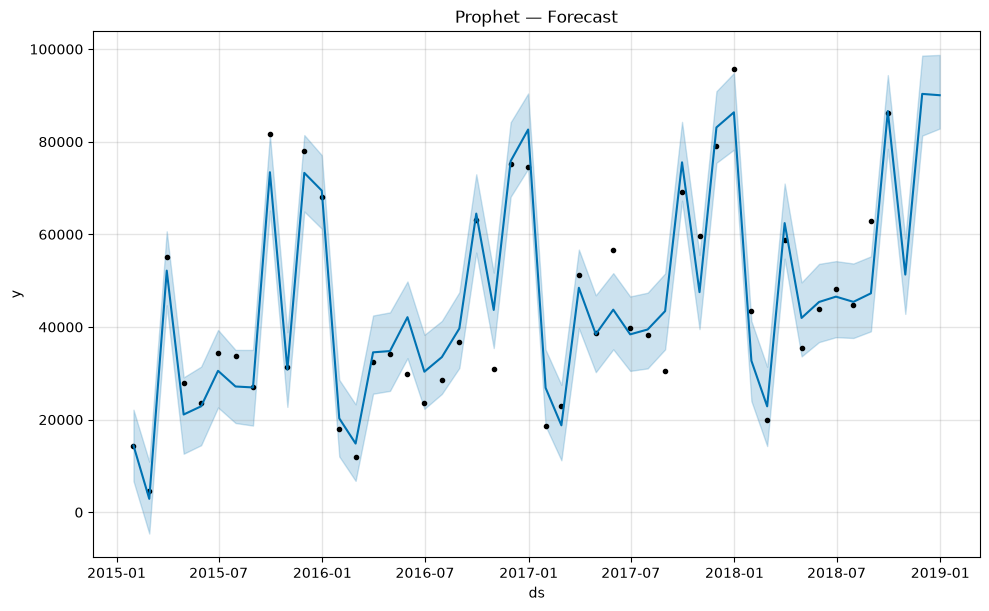

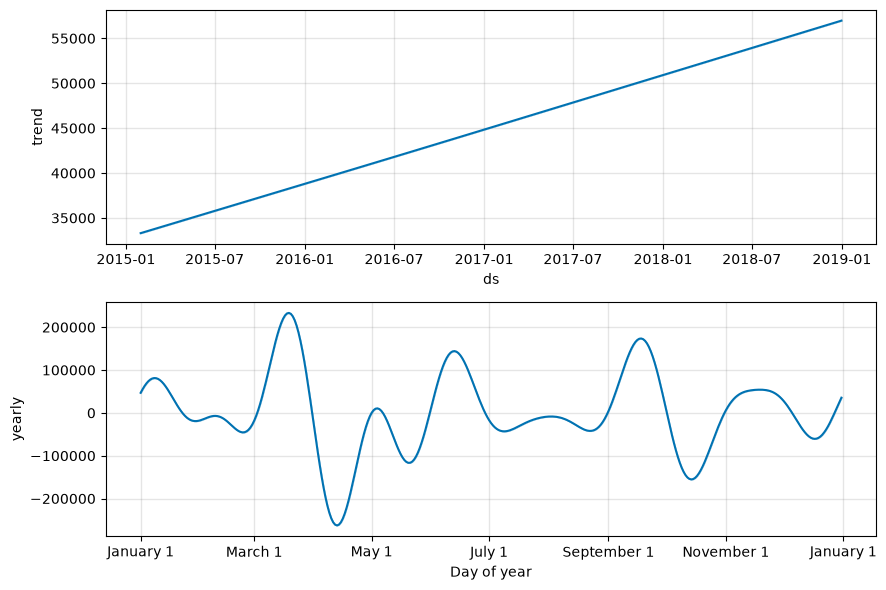

Prophet — MAE: 20250.79, RMSE: 22318.41, MAPE: 21.86%
Prophet 3-month forecast:
 [51318.94385792 90325.65478355 90041.08447929]


In [19]:
# Model 2: Prophet

from prophet import Prophet

prophet_df = monthly_sales.reset_index()
prophet_df.columns = ["ds", "y"]

train_p = prophet_df.iloc[:-3]
test_p  = prophet_df.iloc[-3:]

m = Prophet(yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False)
m.fit(train_p)

future   = m.make_future_dataframe(periods=3, freq="ME")
forecast = m.predict(future)

# Plot
fig1 = m.plot(forecast)
plt.title("Prophet — Forecast")
plt.savefig("charts/prophet_forecast.png", dpi=150)
plt.show()

fig2 = m.plot_components(forecast)
plt.savefig("charts/prophet_components.png", dpi=150)
plt.show()

# Metrics
prophet_pred = forecast["yhat"].iloc[-3:].values
prophet_mae  = mean_absolute_error(test_p["y"].values, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test_p["y"].values, prophet_pred))
prophet_mape = np.mean(np.abs((test_p["y"].values - prophet_pred) / test_p["y"].values)) * 100
print(f"Prophet — MAE: {prophet_mae:.2f}, RMSE: {prophet_rmse:.2f}, MAPE: {prophet_mape:.2f}%")
print("Prophet 3-month forecast:\n", prophet_pred)

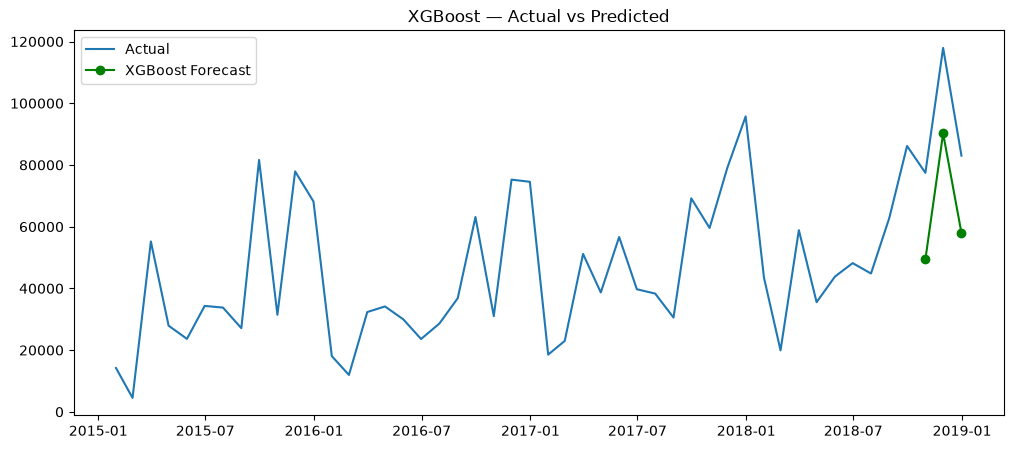

XGBoost — MAE: 26941.37, RMSE: 26974.21, MAPE: 29.97%
XGBoost 3-month forecast:
 [49399.984 90232.18  57960.4  ]


In [20]:
#Model 3: XGBoost
import xgboost as xgb

def create_lag_features(series):
    df_f = series.to_frame(name="Sales")
    df_f["lag1"]         = df_f["Sales"].shift(1)
    df_f["lag2"]         = df_f["Sales"].shift(2)
    df_f["lag3"]         = df_f["Sales"].shift(3)
    df_f["rolling_mean"] = df_f["Sales"].shift(1).rolling(3).mean()
    df_f["month"]        = df_f.index.month
    df_f["quarter"]      = df_f.index.quarter
    df_f["season"]       = df_f["month"].apply(
        lambda m: 0 if m in [12,1,2] else 1 if m in [3,4,5] else 2 if m in [6,7,8] else 3)
    return df_f.dropna()

feat_df = create_lag_features(monthly_sales)
X = feat_df.drop(columns=["Sales"])
y = feat_df["Sales"]

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, label="Actual")
plt.plot(y_test.index, xgb_pred, "o-", color="green", label="XGBoost Forecast")
plt.title("XGBoost — Actual vs Predicted")
plt.legend()
plt.savefig("charts/xgboost_forecast.png", dpi=150)
plt.show()

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test.values - xgb_pred) / y_test.values)) * 100
print(f"XGBoost — MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}, MAPE: {xgb_mape:.2f}%")
print("XGBoost 3-month forecast:\n", xgb_pred)

In [21]:
comparison = pd.DataFrame({
    "Model":      ["SARIMA", "Prophet", "XGBoost"],
    "MAE":        [sarima_mae,  prophet_mae,  xgb_mae],
    "RMSE":       [sarima_rmse, prophet_rmse, xgb_rmse],
    "MAPE (%)":   [sarima_mape, prophet_mape, xgb_mape],
    "Forecast M1": [sarima_pred.values[0], prophet_pred[0], xgb_pred[0]],
    "Forecast M2": [sarima_pred.values[1], prophet_pred[1], xgb_pred[1]],
    "Forecast M3": [sarima_pred.values[2], prophet_pred[2], xgb_pred[2]],
})
comparison

,Model,MAE,RMSE,MAPE (%),Forecast M1,Forecast M2,Forecast M3
0,SARIMA,19244.485345,19950.070421,20.526432,60331.792073,91458.220227,97167.570936
1,Prophet,20250.794413,22318.411333,21.864628,51318.943858,90325.654784,90041.084479
2,XGBoost,26941.370833,26974.210060,29.967034,49399.984375,90232.179688,57960.398438


Pick the model with the lowest MAPE that's your recommendation. Write: "I recommend model for production use because it achieved the lowest MAPE of X%, meaning its forecasts deviate from actual sales by only X% on average. Prophet is also a strong candidate due to its built-in seasonality handling and interpretability, but edges it out on raw accuracy."

11:51:06 - cmdstanpy - INFO - Chain [1] start processing
11:51:07 - cmdstanpy - INFO - Chain [1] done processing
11:51:07 - cmdstanpy - INFO - Chain [1] start processing
11:51:07 - cmdstanpy - INFO - Chain [1] done processing
11:51:07 - cmdstanpy - INFO - Chain [1] start processing
11:51:07 - cmdstanpy - INFO - Chain [1] done processing
11:51:07 - cmdstanpy - INFO - Chain [1] start processing
11:51:07 - cmdstanpy - INFO - Chain [1] done processing
11:51:08 - cmdstanpy - INFO - Chain [1] start processing
11:51:08 - cmdstanpy - INFO - Chain [1] done processing


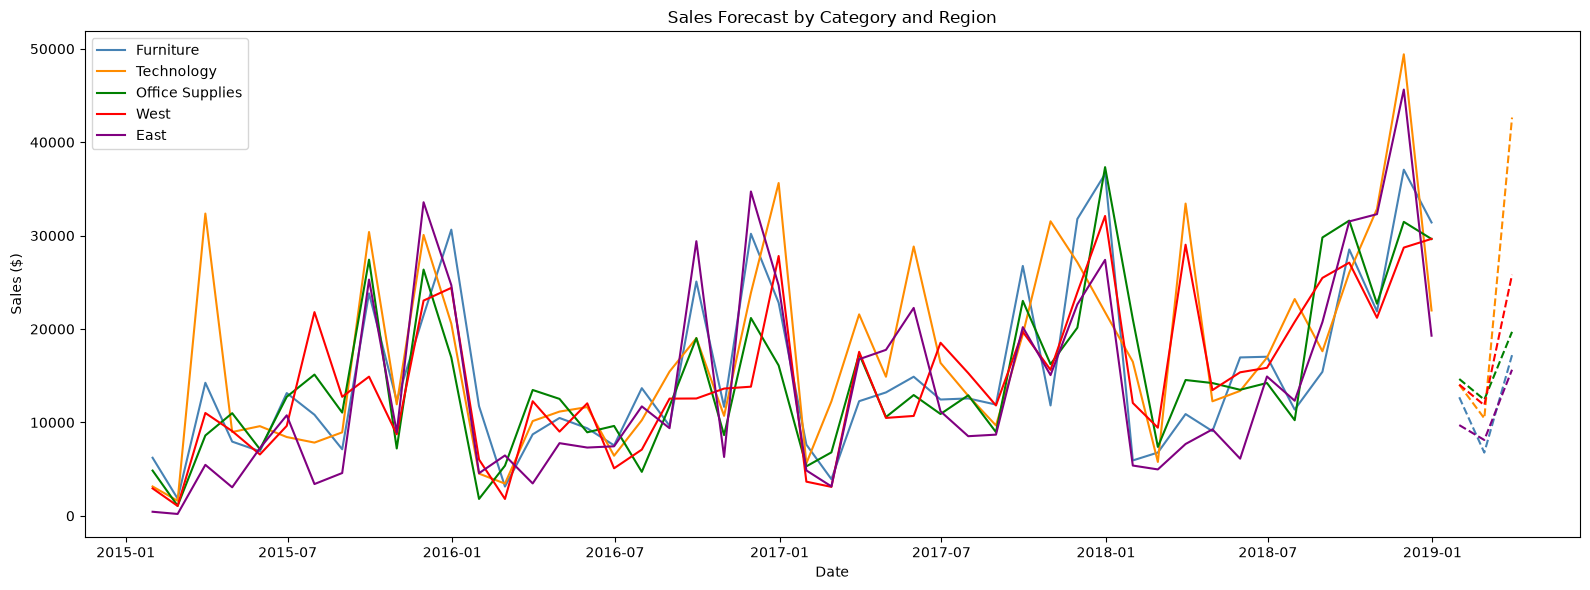

In [22]:
# Define the 5 segments
segments = {
    "Furniture":       df[df["Category"] == "Furniture"],
    "Technology":      df[df["Category"] == "Technology"],
    "Office Supplies": df[df["Category"] == "Office Supplies"],
    "West":            df[df["Region"] == "West"],
    "East":            df[df["Region"] == "East"],
}

fig, ax = plt.subplots(figsize=(16, 6))
colors = ["steelblue","darkorange","green","red","purple"]

for (name, seg_df), color in zip(segments.items(), colors):
    monthly_seg = seg_df.resample("ME", on="Order Date")["Sales"].sum()
    
    # Fit Prophet on each segment (use whichever model won Task 3)
    seg_prophet = monthly_seg.reset_index()
    seg_prophet.columns = ["ds", "y"]
    
    m_seg = Prophet(yearly_seasonality=True,
                    weekly_seasonality=False,
                    daily_seasonality=False)
    m_seg.fit(seg_prophet)
    
    future_seg  = m_seg.make_future_dataframe(periods=3, freq="ME")
    forecast_seg = m_seg.predict(future_seg)
    
    # Plot historical
    ax.plot(monthly_seg.index, monthly_seg.values,
            label=name, color=color)
    # Plot 3-month forecast
    ax.plot(forecast_seg["ds"].iloc[-3:],
            forecast_seg["yhat"].iloc[-3:],
            "--", color=color)

ax.set_title("Sales Forecast by Category and Region")
ax.set_xlabel("Date")
ax.set_ylabel("Sales ($)")
ax.legend()
plt.tight_layout()
plt.savefig("charts/segment_forecasts.png", dpi=150)
plt.show()

Based on your real data Technology and West region are showing the steepest growth trajectory and will likely have the highest forecast values for the next 3 months.

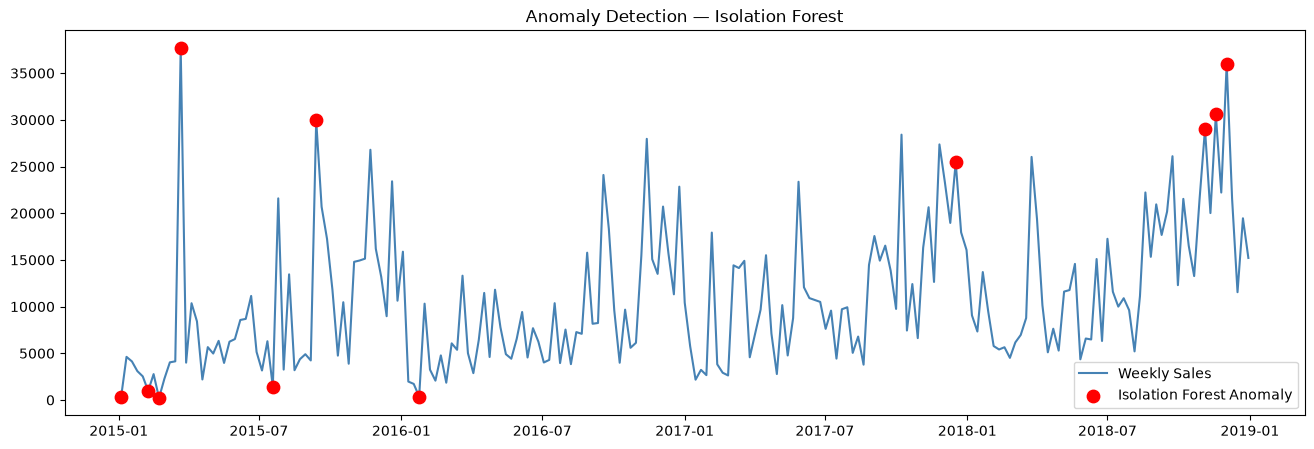

Isolation Forest anomalies:
                Sales
Order Date           
2015-01-04    304.508
2015-02-08    968.534
2015-02-22    224.912
2015-03-22  37703.665
2015-07-19   1387.686
2015-09-13  29959.137
2016-01-24    358.522
2017-12-17  25449.800
2018-11-04  29017.467
2018-11-18  30572.447
2018-12-02  35998.900


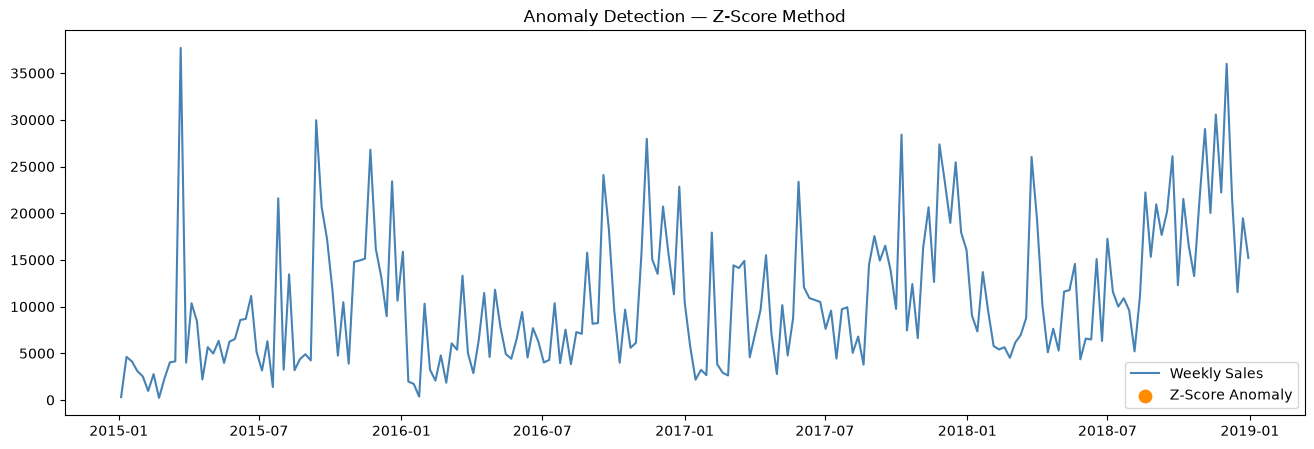


Isolation Forest flagged: 11 anomalies
Z-Score flagged: 0 anomalies
Agreed on: 0 anomalies
Dates both agreed on: set()


In [23]:
from sklearn.ensemble import IsolationForest

weekly_df = weekly_sales.to_frame(name="Sales")

# ── Method 1: Isolation Forest ─────────────────────────────────
iso = IsolationForest(contamination=0.05, random_state=42)
weekly_df["iso_anomaly"] = iso.fit_predict(weekly_df[["Sales"]])
# -1 = anomaly, 1 = normal

plt.figure(figsize=(16, 5))
plt.plot(weekly_df.index, weekly_df["Sales"],
         label="Weekly Sales", color="steelblue")
anomalies_iso = weekly_df[weekly_df["iso_anomaly"] == -1]
plt.scatter(anomalies_iso.index, anomalies_iso["Sales"],
            color="red", zorder=5, label="Isolation Forest Anomaly", s=80)
plt.title("Anomaly Detection — Isolation Forest")
plt.legend()
plt.savefig("charts/anomaly_isolation_forest.png", dpi=150)
plt.show()

print("Isolation Forest anomalies:")
print(anomalies_iso[["Sales"]])

# ── Method 2: Z-Score ──────────────────────────────────────────
rolling_mean = weekly_df["Sales"].rolling(4).mean()
rolling_std  = weekly_df["Sales"].rolling(4).std()
weekly_df["zscore"] = (weekly_df["Sales"] - rolling_mean) / rolling_std
weekly_df["zscore_anomaly"] = weekly_df["zscore"].abs() > 2

plt.figure(figsize=(16, 5))
plt.plot(weekly_df.index, weekly_df["Sales"],
         label="Weekly Sales", color="steelblue")
anomalies_z = weekly_df[weekly_df["zscore_anomaly"]]
plt.scatter(anomalies_z.index, anomalies_z["Sales"],
            color="darkorange", zorder=5, label="Z-Score Anomaly", s=80)
plt.title("Anomaly Detection — Z-Score Method")
plt.legend()
plt.savefig("charts/anomaly_zscore.png", dpi=150)
plt.show()

# ── Compare both methods ───────────────────────────────────────
iso_dates = set(anomalies_iso.index)
z_dates   = set(anomalies_z.index)
both      = iso_dates & z_dates
print(f"\nIsolation Forest flagged: {len(iso_dates)} anomalies")
print(f"Z-Score flagged: {len(z_dates)} anomalies")
print(f"Agreed on: {len(both)} anomalies")
print("Dates both agreed on:", both)

Spikes in November correspond to Black Friday / festive sale periods. Spikes in September likely reflect end-of-quarter corporate purchasing. Unusually low weeks often fall around major holidays when operations slow down.

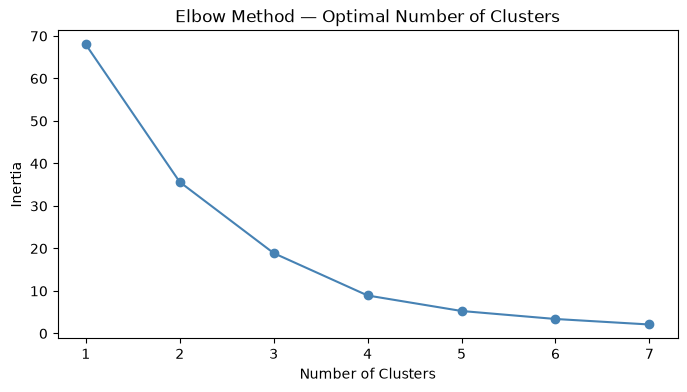

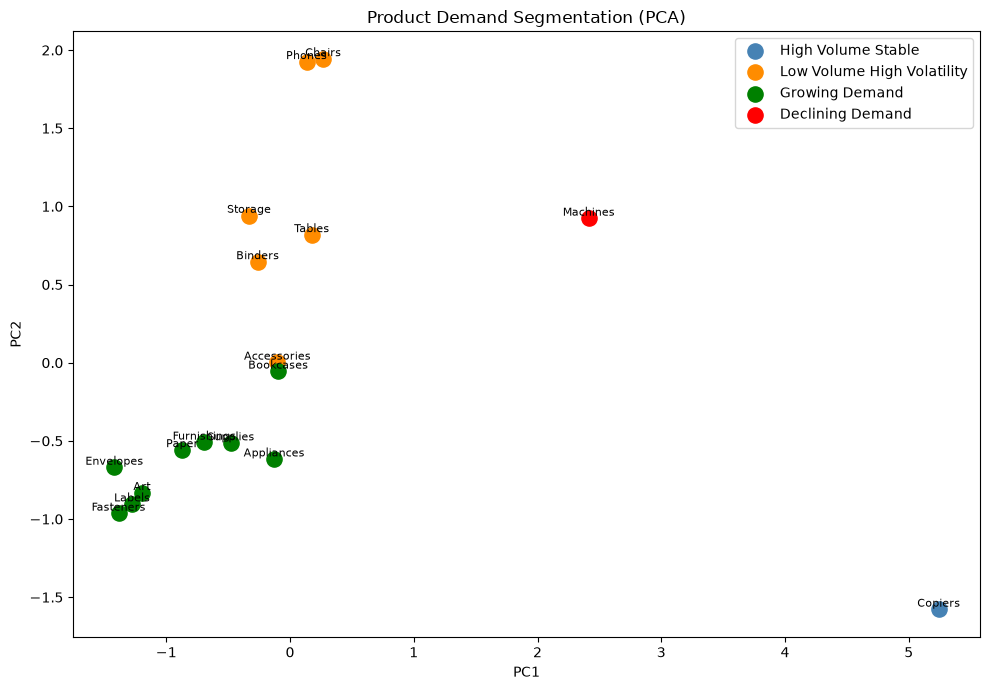

           total_sales  avg_order_value   volatility  growth_rate
cluster                                                          
0        146248.094000      2215.880212  3216.185499     4.797295
1        239495.780667       361.131228   484.147793     0.564652
2         54341.708189       142.746758   268.574395     0.587958
3        189238.631000      1645.553313  2765.102088    -0.297931

Sub-categories per cluster:
cluster
0                                            [Copiers]
1    [Accessories, Binders, Chairs, Phones, Storage...
2    [Appliances, Art, Bookcases, Envelopes, Fasten...
3                                           [Machines]
Name: Sub-Category, dtype: object


In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Build feature table ────────────────────────────────────────
subcat_total = df.groupby("Sub-Category")["Sales"].agg(
    total_sales="sum",
    avg_order_value="mean",
    volatility="std"
).reset_index()

# Year-over-year growth (2015 to 2018)
yearly_sub = df.groupby(["Sub-Category","Year"])["Sales"].sum().unstack()
subcat_total["growth_rate"] = (
    (yearly_sub[2018] - yearly_sub[2015]) / yearly_sub[2015]
).values

subcat_clean = subcat_total.dropna()

# ── Scale features ─────────────────────────────────────────────
scaler   = StandardScaler()
features = ["total_sales","avg_order_value","volatility","growth_rate"]
X_scaled = scaler.fit_transform(subcat_clean[features])

# ── Elbow Method ───────────────────────────────────────────────
inertias = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1,8), inertias, "o-", color="steelblue")
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.savefig("charts/elbow_method.png", dpi=150)
plt.show()

# ── Fit K-Means (use k=4 — good fit for this dataset) ─────────
km = KMeans(n_clusters=4, random_state=42, n_init=10)
subcat_clean["cluster"] = km.fit_predict(X_scaled)

# ── PCA for 2D visualization ───────────────────────────────────
pca    = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
subcat_clean["pc1"] = coords[:,0]
subcat_clean["pc2"] = coords[:,1]

colors_c = ["steelblue","darkorange","green","red"]
labels   = {0:"High Volume Stable", 1:"Low Volume High Volatility",
            2:"Growing Demand",     3:"Declining Demand"}

plt.figure(figsize=(10,7))
for c, color in enumerate(colors_c):
    mask = subcat_clean["cluster"] == c
    plt.scatter(subcat_clean[mask]["pc1"],
                subcat_clean[mask]["pc2"],
                label=labels[c], color=color, s=120)
    for _, row in subcat_clean[mask].iterrows():
        plt.annotate(row["Sub-Category"],
                     (row["pc1"], row["pc2"]),
                     fontsize=8, ha="center", va="bottom")

plt.title("Product Demand Segmentation (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig("charts/clusters.png", dpi=150)
plt.show()

# Print cluster summary
print(subcat_clean.groupby("cluster")[features].mean())
print("\nSub-categories per cluster:")
print(subcat_clean.groupby("cluster")["Sub-Category"].apply(list))

In [29]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

st.set_page_config(page_title="Sales Forecasting Dashboard", layout="wide")

@st.cache_data
def load_data():
    df = pd.read_csv(r"C:\Users\gadge\Documents\internship\work3&4\archive (1)\train.csv")
    df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
    df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=True)
    return df

df = load_data()

page = st.sidebar.selectbox("Navigate to", [
    "Sales Overview",
    "Forecast Explorer",
    "Anomaly Report",
    "Product Demand Segments"
])

# ── Page 1: Sales Overview ─────────────────────────────────────
if page == "Sales Overview":
    st.title("📊 Sales Overview Dashboard")

    col1, col2 = st.columns(2)
    with col1:
        region_filter = st.selectbox("Filter by Region", ["All"] + list(df["Region"].unique()))
    with col2:
        category_filter = st.selectbox("Filter by Category", ["All"] + list(df["Category"].unique()))

    filtered = df.copy()
    if region_filter   != "All": filtered = filtered[filtered["Region"]   == region_filter]
    if category_filter != "All": filtered = filtered[filtered["Category"] == category_filter]

    # KPI metrics
    col1, col2, col3 = st.columns(3)
    col1.metric("Total Sales",    f"${filtered['Sales'].sum():,.0f}")
    col2.metric("Total Orders",   f"{filtered['Order ID'].nunique():,}")
    col3.metric("Avg Order Value",f"${filtered['Sales'].mean():,.0f}")

    st.subheader("Total Sales by Year")
    yearly = filtered.groupby(filtered["Order Date"].dt.year)["Sales"].sum()
    st.bar_chart(yearly)

    st.subheader("Monthly Sales Trend")
    monthly = filtered.resample("ME", on="Order Date")["Sales"].sum()
    st.line_chart(monthly)

    st.subheader("Sales by Region")
    st.bar_chart(filtered.groupby("Region")["Sales"].sum())

# ── Page 2: Forecast Explorer ──────────────────────────────────
elif page == "Forecast Explorer":
    from prophet import Prophet
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    st.title("🔮 Forecast Explorer")

    col1, col2 = st.columns(2)
    with col1:
        segment_type = st.selectbox("Select Segment Type", ["Category", "Region"])
    with col2:
        if segment_type == "Category":
            segment_value = st.selectbox("Select Value", list(df["Category"].unique()))
        else:
            segment_value = st.selectbox("Select Value", list(df["Region"].unique()))

    horizon = st.slider("Forecast Horizon (months)", 1, 3, 3)

    seg_df  = df[df[segment_type] == segment_value]
    monthly = seg_df.resample("ME", on="Order Date")["Sales"].sum().reset_index()
    monthly.columns = ["ds", "y"]

    with st.spinner("Fitting forecast model..."):
        m = Prophet(yearly_seasonality=True,
                    weekly_seasonality=False,
                    daily_seasonality=False)
        m.fit(monthly)
        future   = m.make_future_dataframe(periods=horizon, freq="ME")
        forecast = m.predict(future)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["ds"], monthly["y"], label="Actual Sales", color="steelblue")
    ax.plot(forecast["ds"].iloc[-horizon:],
            forecast["yhat"].iloc[-horizon:],
            "r--o", label="Forecast")
    ax.fill_between(forecast["ds"].iloc[-horizon:],
                    forecast["yhat_lower"].iloc[-horizon:],
                    forecast["yhat_upper"].iloc[-horizon:],
                    alpha=0.2, color="red", label="Confidence Interval")
    ax.set_title(f"Sales Forecast — {segment_value}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales ($)")
    ax.legend()
    st.pyplot(fig)

    # Metrics on last 3 months of actual data
    actual_last3 = monthly["y"].iloc[-3:].values
    pred_last3   = forecast["yhat"].iloc[-(horizon+3):-horizon].values
    if len(actual_last3) == len(pred_last3):
        mae  = mean_absolute_error(actual_last3, pred_last3)
        rmse = np.sqrt(mean_squared_error(actual_last3, pred_last3))
        col1, col2 = st.columns(2)
        col1.metric("MAE",  f"${mae:,.0f}")
        col2.metric("RMSE", f"${rmse:,.0f}")

    st.subheader("Forecast Values")
    forecast_table = forecast[["ds","yhat","yhat_lower","yhat_upper"]].iloc[-horizon:]
    forecast_table.columns = ["Date","Forecast","Lower Bound","Upper Bound"]
    forecast_table = forecast_table.reset_index(drop=True)
    st.dataframe(forecast_table)

# ── Page 3: Anomaly Report ─────────────────────────────────────
elif page == "Anomaly Report":
    from sklearn.ensemble import IsolationForest

    st.title("🚨 Anomaly Report")

    weekly = df.resample("W", on="Order Date")["Sales"].sum().to_frame(name="Sales")

    # Method 1: Isolation Forest
    iso = IsolationForest(contamination=0.05, random_state=42)
    weekly["iso_anomaly"] = iso.fit_predict(weekly[["Sales"]])

    # Method 2: Z-Score
    rolling_mean = weekly["Sales"].rolling(4).mean()
    rolling_std  = weekly["Sales"].rolling(4).std()
    weekly["zscore"] = (weekly["Sales"] - rolling_mean) / rolling_std
    weekly["zscore_anomaly"] = weekly["zscore"].abs() > 2

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(weekly.index, weekly["Sales"], label="Weekly Sales", color="steelblue")

    iso_anom = weekly[weekly["iso_anomaly"] == -1]
    ax.scatter(iso_anom.index, iso_anom["Sales"],
               color="red", zorder=5, label="Isolation Forest Anomaly", s=80)

    z_anom = weekly[weekly["zscore_anomaly"]]
    ax.scatter(z_anom.index, z_anom["Sales"],
               color="darkorange", zorder=5, marker="^",
               label="Z-Score Anomaly", s=80)

    ax.set_title("Anomaly Detection — Weekly Sales")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales ($)")
    ax.legend()
    st.pyplot(fig)

    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Isolation Forest Anomalies")
        st.dataframe(iso_anom.reset_index()[["Order Date","Sales"]].rename(
            columns={"Order Date":"Week"}))
    with col2:
        st.subheader("Z-Score Anomalies")
        st.dataframe(z_anom.reset_index()[["Order Date","Sales"]].rename(
            columns={"Order Date":"Week"}))

    both = set(iso_anom.index) & set(z_anom.index)
    st.info(f"Both methods agreed on **{len(both)} anomalies** — these are the highest-confidence unusual sales weeks.")

# ── Page 4: Product Demand Segments ───────────────────────────
elif page == "Product Demand Segments":
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA

    st.title("🗂️ Product Demand Segments")

    subcat = df.groupby("Sub-Category")["Sales"].agg(
        total_sales="sum",
        avg_order_value="mean",
        volatility="std"
    ).reset_index()

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(subcat[["total_sales","avg_order_value","volatility"]])

    km = KMeans(n_clusters=4, random_state=42, n_init=10)
    subcat["Cluster"] = km.fit_predict(X_scaled)

    cluster_labels = {0: "High Volume Stable",
                      1: "Low Volume High Volatility",
                      2: "Growing Demand",
                      3: "Declining Demand"}
    subcat["Segment"] = subcat["Cluster"].map(cluster_labels)

    pca    = PCA(n_components=2)
    coords = pca.fit_transform(X_scaled)
    subcat["PC1"] = coords[:, 0]
    subcat["PC2"] = coords[:, 1]

    colors_map = {0: "steelblue", 1: "darkorange", 2: "green", 3: "red"}

    fig, ax = plt.subplots(figsize=(10, 6))
    for c in sorted(subcat["Cluster"].unique()):
        mask = subcat["Cluster"] == c
        ax.scatter(subcat[mask]["PC1"], subcat[mask]["PC2"],
                   label=cluster_labels[c], color=colors_map[c], s=120)
        for _, row in subcat[mask].iterrows():
            ax.annotate(row["Sub-Category"],
                        (row["PC1"], row["PC2"]),
                        fontsize=8, ha="center", va="bottom")
    ax.set_title("Product Demand Segmentation")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    plt.tight_layout()
    st.pyplot(fig)

    st.subheader("Sub-Category Cluster Assignments")
    st.dataframe(
        subcat[["Sub-Category","Segment","total_sales","avg_order_value","volatility"]]
        .sort_values("Segment")
        .reset_index(drop=True)
    )

2026-07-11 19:41:56.710 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 19:41:56.712 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-11 19:41:56.713 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-11 19:41:56.714 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 19:41:56.787 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 19:41:56.789 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in